In [28]:
import os
from nilearn import plotting
from nilearn.image import load_img, resample_to_img
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib import cm
import matplotlib as mpl

In [29]:
# Directory for saving figures
figures_dir = '../figures'
os.makedirs(figures_dir, exist_ok=True)

In [30]:
# Loading the background image
# average T1w of our sample
#avg_T1_path = '/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/average_T1w.nii'
avg_T1_path = '/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/avg_T1w/masked_avg_T1.nii'
avg_T1 = load_img(avg_T1_path)

In [31]:
mask_dir = '/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/masks/MNI152NLin2009cAsym'
mask_files = [os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.nii')]

In [32]:
masks = {}
for mask_file in mask_files:
    roi_name = (os.path.basename(mask_file)).split('_')[0]
    mask_img = load_img(mask_file)
    masks[roi_name] = mask_img

In [33]:
# Use tab10 colormap for ROI colors
roi_colors = [cm.tab10(i) for i in range(10)]
roi_cmps = [mpl.colors.LinearSegmentedColormap.from_list('', [c, c]) for c in roi_colors]

# Q-value ROIs

/Users/hugofluhr/miniforge3/envs/neuroim/lib/python3.10/site-packages/numpy/ma/core.py:2892: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


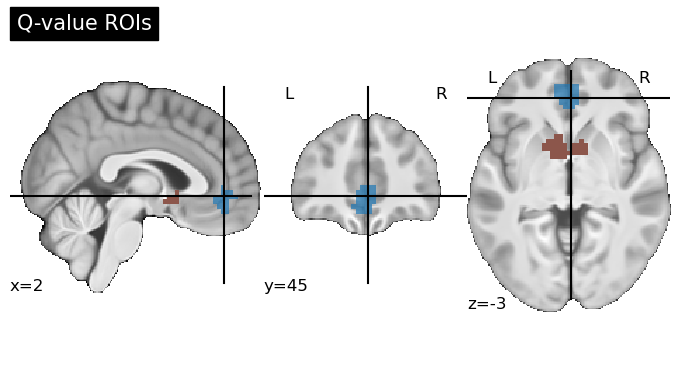

In [56]:
# Q-value ROI plot
display = plotting.plot_roi(
    masks['vmpfc'],
    bg_img=avg_T1,
    black_bg=False,
    title='Q-value ROIs',
    display_mode='ortho',
    draw_cross=True,
    cut_coords=(2, 45, -3),
    cmap=roi_cmps[0],
    colorbar=False,
    dim=0
)

display.add_overlay(
    masks['striatum'],
    cmap=roi_cmps[5]
)

display.savefig(
    f"{figures_dir}/Q_value_ROIs.png",
    dpi=600
)

plotting.show()

# H-value ROIs

/Users/hugofluhr/miniforge3/envs/neuroim/lib/python3.10/site-packages/numpy/ma/core.py:2892: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


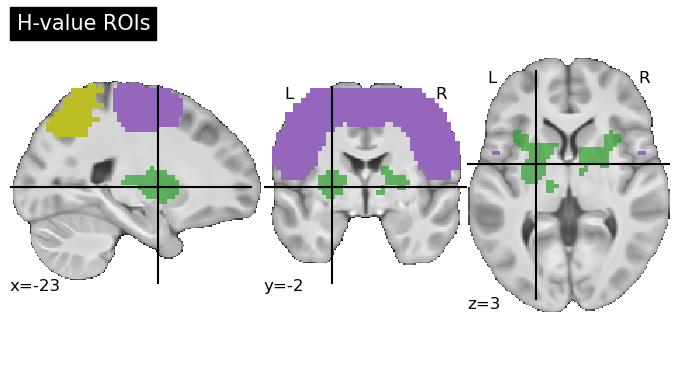

In [57]:
# First ROI (creates the figure)
display = plotting.plot_roi(
    masks['habit'],
    bg_img=avg_T1,
    title='H-value ROIs',
    black_bg=False,
    display_mode='ortho',
    draw_cross=True,
    cmap=roi_cmps[2],
    colorbar=False,
    dim=0
)

# Second ROI: Parietal
display.add_overlay(
    masks['parietal'],
    cmap=roi_cmps[8]
)

# Third ROI: Motor
display.add_overlay(
    masks['motor'],
    cmap=roi_cmps[4]
)

display.savefig(
    f"{figures_dir}/H_value_ROIs.png",
    dpi=600
)

plotting.show()

# GLM1


## First stim x Qval

In [36]:
glm1_first_stim_x_Qval = '/Users/hugofluhr/phd_local/data/LearningHabits/spm_outputs_noSDC/glm2_all_runs_scrubbed_2025-12-11-12-44/second-lvl/first_stimxqval/spmT_0001.nii'

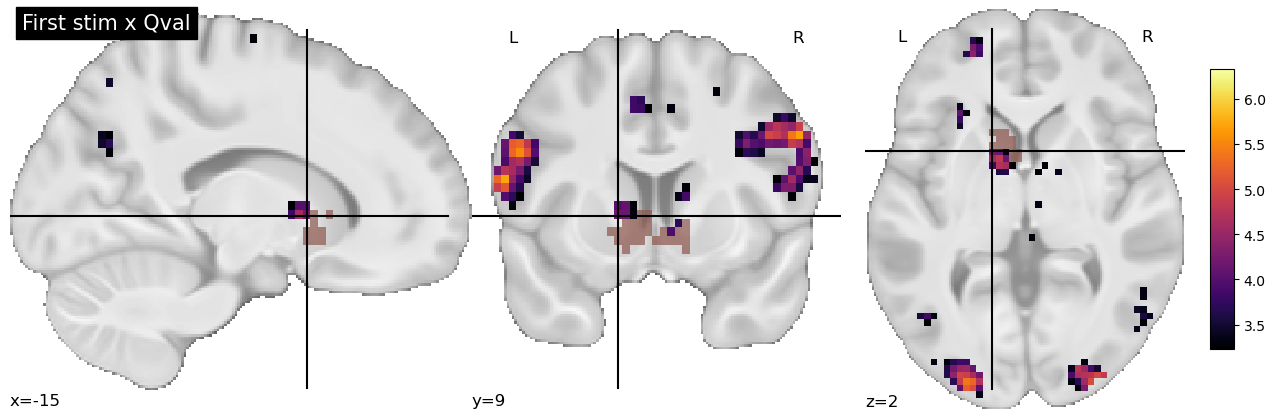

In [37]:
fig = plt.figure(figsize=(12, 4))

display = plotting.plot_anat(
    avg_T1,
    black_bg=False,
    title="First stim x Qval",
    display_mode="ortho",
    draw_cross=True,
    cut_coords=(-15, 9, 2),
    threshold=200,
    dim='auto',
    colorbar=False,
    figure=fig
)

display.add_overlay(
    masks["striatum"],
    cmap=roi_cmps[5],
    transparency=0.7,
)

display.add_overlay(
    glm1_first_stim_x_Qval,
    vmin=3.23,
    vmax=6.33,
    colorbar=False,
    cmap='inferno'
)

cax = fig.add_axes([1, 0.15, 0.02, 0.70])
norm = mpl.colors.Normalize(vmin=3.23, vmax=6.33)
cb = mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.inferno, norm=norm)

fig.savefig(f"{figures_dir}/GLM1_first_stim_x_Qval_ortho.png", dpi=300, bbox_inches='tight')
plotting.show()

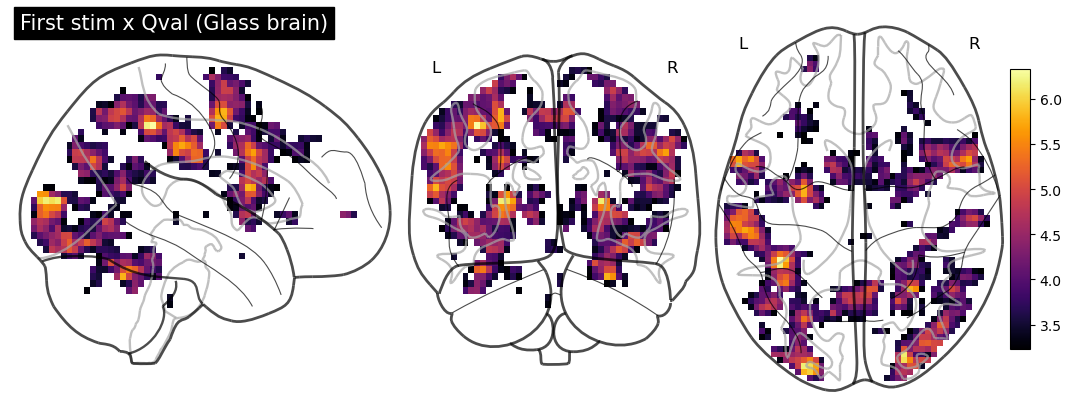

In [38]:
# Glass brain
fig = plt.figure(figsize=(10, 4))

display = plotting.plot_glass_brain(
    glm1_first_stim_x_Qval,
    black_bg=False,
    title="First stim x Qval (Glass brain)",
    display_mode="ortho",
    figure=fig,
    vmin=3.23,
    vmax=6.33,
    colorbar=False,
    cmap='inferno',
)

cax = fig.add_axes([1, 0.15, 0.02, 0.70])
norm = mpl.colors.Normalize(vmin=3.23, vmax=6.33)
cb = mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.inferno, norm=norm)

fig.savefig(f"{figures_dir}/GLM1_first_stim_x_Qval_glass.png", dpi=300, bbox_inches='tight')
plotting.show()

## Second stim x Hval

In [39]:
glm1_second_stim_x_Hval = '/Users/hugofluhr/phd_local/data/LearningHabits/spm_outputs_noSDC/glm2_all_runs_scrubbed_2025-12-11-12-44/second-lvl/second_stimxhval/spmT_0001.nii'

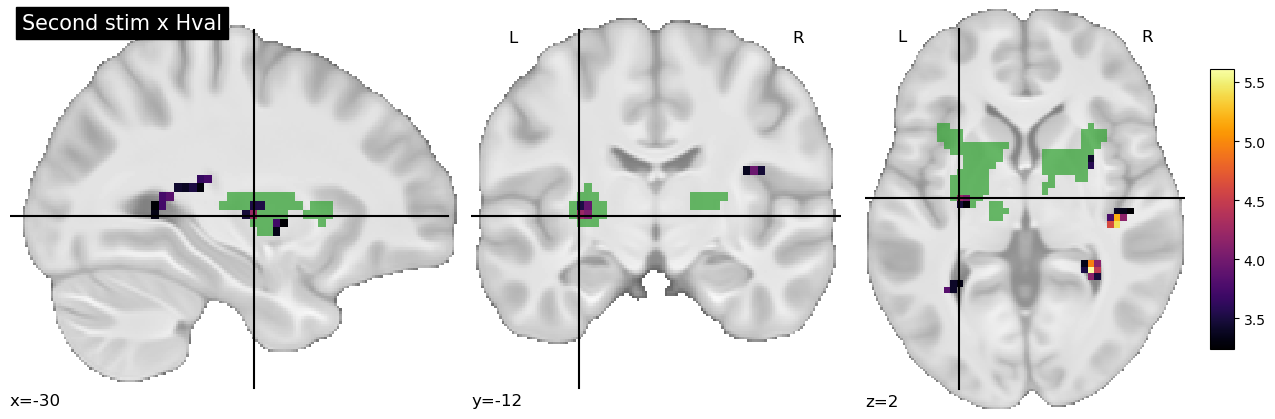

In [40]:
fig = plt.figure(figsize=(12, 4))

display = plotting.plot_anat(
    avg_T1,
    black_bg=False,
    title="Second stim x Hval",
    display_mode="ortho",
    draw_cross=True,
    cut_coords=(-30, -12, 2),
    threshold=200,
    dim='auto',
    colorbar=False,
    figure=fig
)

display.add_overlay(
    masks["habit"],
    cmap=roi_cmps[2],
    transparency=0.7,
)

display.add_overlay(
    glm1_second_stim_x_Hval,
    vmin=3.24,
    vmax=5.61,
    colorbar=False,
    cmap='inferno'
)

cax = fig.add_axes([1, 0.15, 0.02, 0.70])
norm = mpl.colors.Normalize(vmin=3.24, vmax=5.61)
cb = mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.inferno, norm=norm)

fig.savefig(f"{figures_dir}/GLM1_second_stim_x_Hval_ortho.png", dpi=300, bbox_inches='tight')
plotting.show()

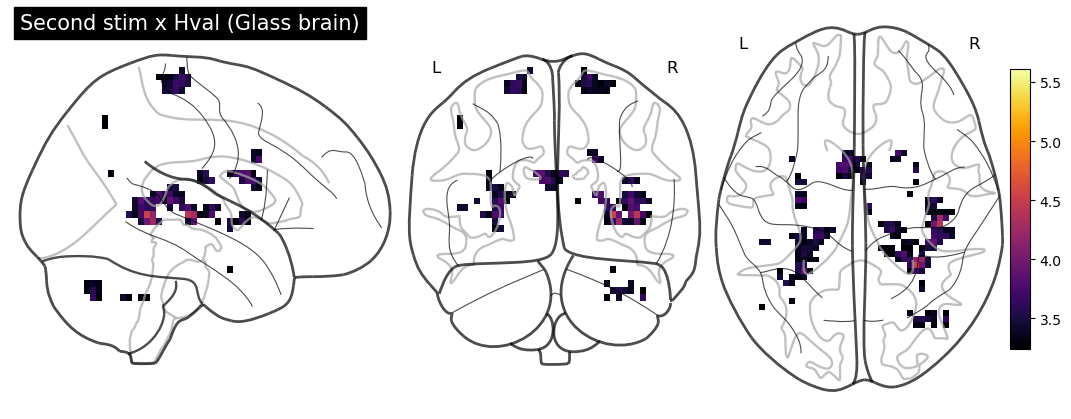

In [41]:
# handle negative values if any
from nilearn.image import math_img
pos_img = math_img(
    "np.where(img > 0, img, 0)",
    img=glm1_second_stim_x_Hval
)

# Glass brain
fig = plt.figure(figsize=(10, 4))

display = plotting.plot_glass_brain(
    pos_img,
    black_bg=False,
    title="Second stim x Hval (Glass brain)",
    display_mode="ortho",
    figure=fig,
    threshold=3.24,
    vmin=3.24,
    vmax=7.61,
    colorbar=False,
    cmap='inferno',
)

cax = fig.add_axes([1, 0.15, 0.02, 0.70])
norm = mpl.colors.Normalize(vmin=3.24, vmax=5.61)
cb = mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.inferno, norm=norm)

fig.savefig(f"{figures_dir}/GLM1_second_stim_x_Hval_glass.png", dpi=300, bbox_inches='tight')
plotting.show()

# GLM2


## Chosen stim x Qval

In [42]:
glm2_chosen_x_Qval = '/Users/hugofluhr/phd_local/data/LearningHabits/spm_outputs_noSDC/glm2_chosen_all_runs_scrubbed_2025-12-11-11-22/second-lvl/second_stimxqval_chosen/spmT_0001.nii'

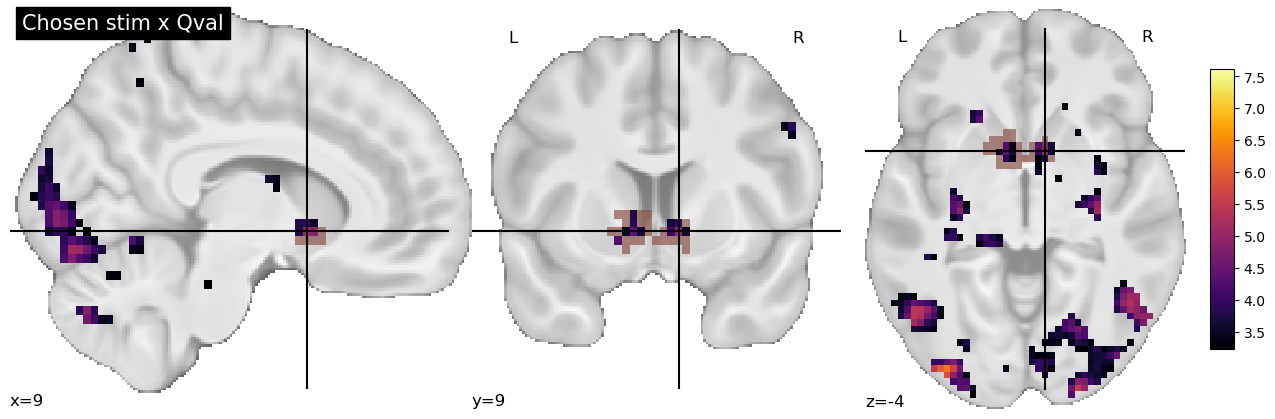

In [43]:
fig = plt.figure(figsize=(12, 4))

display = plotting.plot_anat(
    avg_T1,
    black_bg=False,
    title="Chosen stim x Qval",
    display_mode="ortho",
    draw_cross=True,
    cut_coords=(9, 9, -4),
    threshold=200,
    dim='auto',
    colorbar=False,
    figure=fig
)

display.add_overlay(
    masks["striatum"],
    cmap=roi_cmps[5],
    transparency=0.7,
)

display.add_overlay(
    glm2_chosen_x_Qval,
    vmin=3.23,
    vmax=7.61,
    colorbar=False,
    cmap='inferno'
)

cax = fig.add_axes([1, 0.15, 0.02, 0.70])
norm = mpl.colors.Normalize(vmin=3.23, vmax=7.61)
cb = mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.inferno, norm=norm)

fig.savefig(f"{figures_dir}/GLM2_chosen_x_Qval_ortho.png", dpi=300, bbox_inches='tight')
plotting.show()

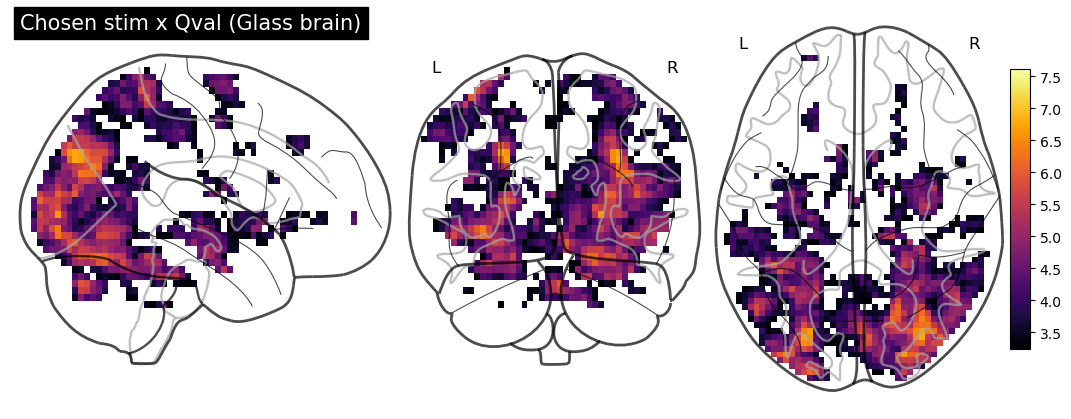

In [44]:
# handle negative values if any
from nilearn.image import math_img
pos_img = math_img(
    "np.where(img > 0, img, 0)",
    img=glm2_chosen_x_Qval
)

# Glass brain
fig = plt.figure(figsize=(10, 4))

display = plotting.plot_glass_brain(
    pos_img,
    black_bg=False,
    title="Chosen stim x Qval (Glass brain)",
    display_mode="ortho",
    figure=fig,
    threshold=3.24,
    vmin=3.24,
    vmax=7.61,
    colorbar=False,
    cmap='inferno',
)

cax = fig.add_axes([1, 0.15, 0.02, 0.70])
norm = mpl.colors.Normalize(vmin=3.24, vmax=7.61)
cb = mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.inferno, norm=norm)

fig.savefig(f"{figures_dir}/GLM2_chosen_x_Qval_glass.png", dpi=300, bbox_inches='tight')
plotting.show()

In [45]:
glm2_chosen_x_Hval = '/Users/hugofluhr/phd_local/data/LearningHabits/spm_outputs_noSDC/glm2_chosen_all_runs_scrubbed_2025-12-11-11-22/second-lvl/second_stimxhval_chosen/spmT_0001.nii'

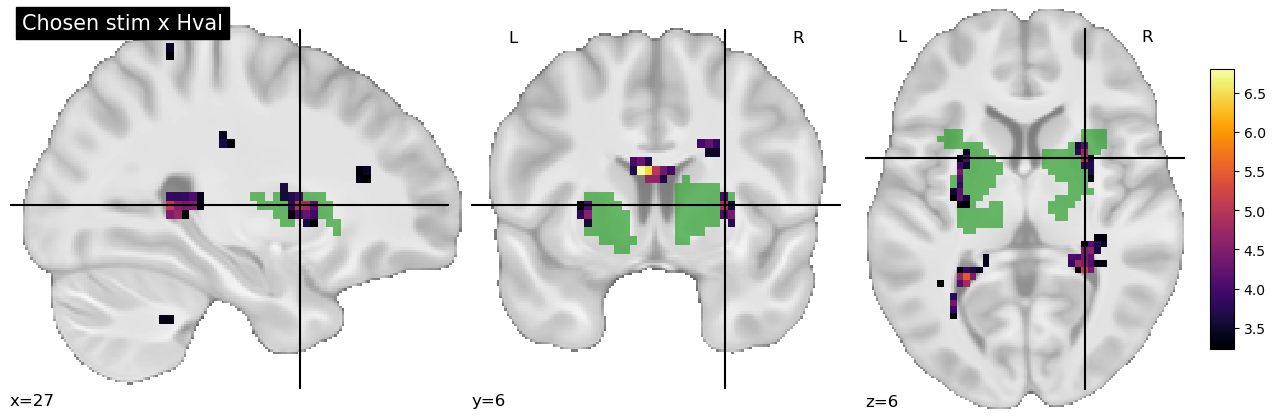

In [46]:
fig = plt.figure(figsize=(12, 4))

display = plotting.plot_anat(
    avg_T1,
    black_bg=False,
    title="Chosen stim x Hval",
    display_mode="ortho",
    draw_cross=True,
    cut_coords=(27, 6, 6),
    threshold=200,
    dim='auto',
    colorbar=False,
    figure=fig
)

display.add_overlay(
    masks["habit"],
    cmap=roi_cmps[2],
    transparency=0.7,
)

display.add_overlay(
    glm2_chosen_x_Hval,
    vmin=3.23,
    vmax=6.8,
    colorbar=False,
    cmap='inferno'
)

cax = fig.add_axes([1, 0.15, 0.02, 0.70])
norm = mpl.colors.Normalize(vmin=3.23, vmax=6.8)
cb = mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.inferno, norm=norm)

fig.savefig(f"{figures_dir}/GLM2_chosen_x_Hval_ortho_habit.png", dpi=300, bbox_inches='tight')
plotting.show()

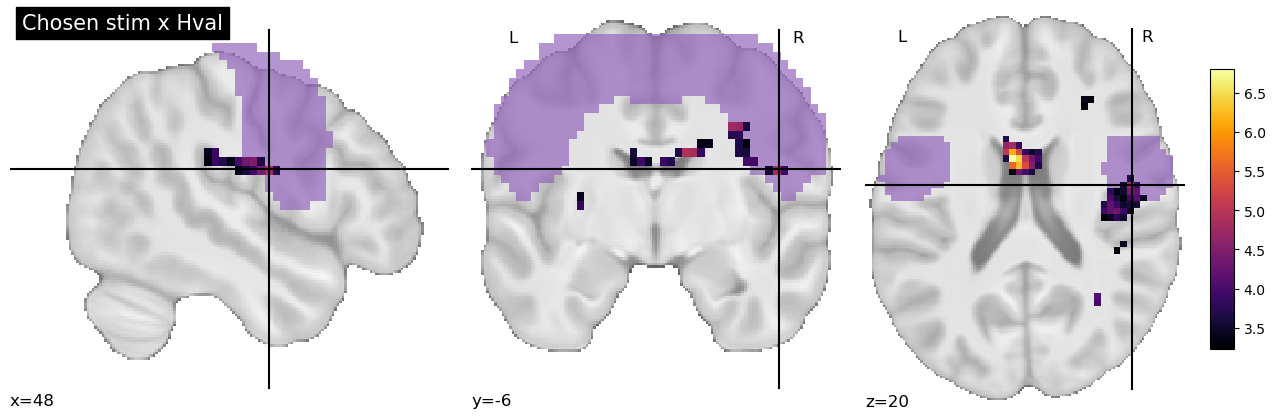

In [47]:
fig = plt.figure(figsize=(12, 4))

display = plotting.plot_anat(
    avg_T1,
    black_bg=False,
    title="Chosen stim x Hval",
    display_mode="ortho",
    draw_cross=True,
    cut_coords=(48, -6, 20),
    threshold=200,
    dim='auto',
    colorbar=False,
    figure=fig
)

display.add_overlay(
    masks["motor"],
    cmap=roi_cmps[4],
    transparency=0.7,
)

display.add_overlay(
    glm2_chosen_x_Hval,
    vmin=3.23,
    vmax=6.8,
    colorbar=False,
    cmap='inferno'
)

cax = fig.add_axes([1, 0.15, 0.02, 0.70])
norm = mpl.colors.Normalize(vmin=3.23, vmax=6.8)
cb = mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.inferno, norm=norm)

fig.savefig(f"{figures_dir}/GLM2_chosen_x_Hval_ortho_motor.png", dpi=300, bbox_inches='tight')
plotting.show()

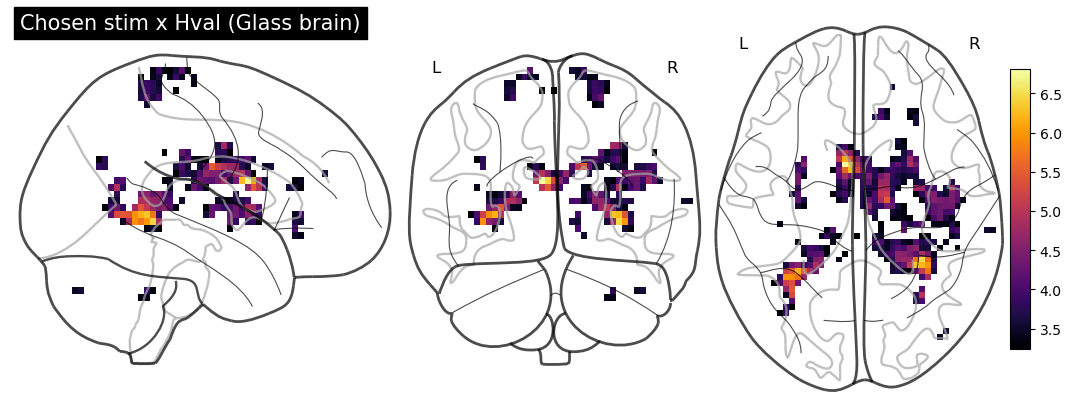

In [48]:
# handle negative values if any
from nilearn.image import math_img
pos_img = math_img(
    "np.where(img > 0, img, 0)",
    img=glm2_chosen_x_Hval
)

# Glass brain
fig = plt.figure(figsize=(10, 4))

display = plotting.plot_glass_brain(
    pos_img,
    black_bg=False,
    title="Chosen stim x Hval (Glass brain)",
    display_mode="ortho",
    figure=fig,
    threshold=3.24,
    vmin=3.24,
    vmax=6.81,
    colorbar=False,
    cmap='inferno',
)

cax = fig.add_axes([1, 0.15, 0.02, 0.70])
norm = mpl.colors.Normalize(vmin=3.24, vmax=6.81)
cb = mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.inferno, norm=norm)

fig.savefig(f"{figures_dir}/GLM2_chosen_x_Hval_glass.png", dpi=300, bbox_inches='tight')
plotting.show()

# GLM3

## Chosen stim x choice variable

In [49]:
glm3_chosen_x_choice_var = '/Users/hugofluhr/phd_local/data/LearningHabits/spm_outputs_noSDC/glm3_chosen_choice_var_scrubbed_2026-04-01-01-29/second-lvl/second_stimxchoiceval_chosen/spmT_0001.nii'

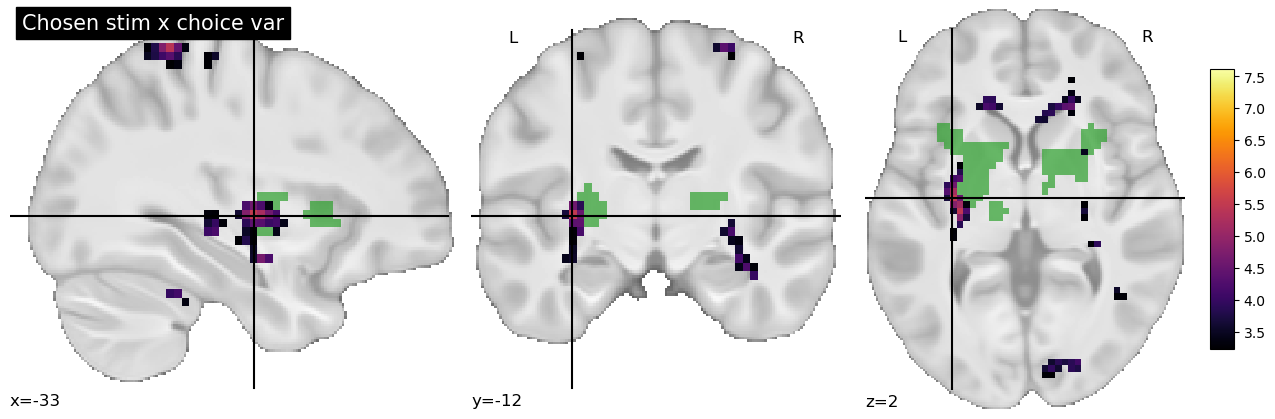

In [50]:
fig = plt.figure(figsize=(12, 4))

display = plotting.plot_anat(
    avg_T1,
    black_bg=False,
    title="Chosen stim x choice var",
    display_mode="ortho",
    draw_cross=True,
    cut_coords=(-33, -12, 2),
    threshold=200,
    dim='auto',
    colorbar=False,
    figure=fig
)

display.add_overlay(
    masks["habit"],
    cmap=roi_cmps[2],
    transparency=0.7,
)

display.add_overlay(
    glm3_chosen_x_choice_var,
    vmin=3.23,
    vmax=7.61,
    colorbar=False,
    cmap='inferno'
)

cax = fig.add_axes([1, 0.15, 0.02, 0.70])
norm = mpl.colors.Normalize(vmin=3.23, vmax=7.61)
cb = mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.inferno, norm=norm)

fig.savefig(f"{figures_dir}/GLM3_chosen_x_choice_var_ortho.png", dpi=300, bbox_inches='tight')
plotting.show()

# PPI

## Chosen stim x  Hval (putamen seed)

In [ ]:
ppi_chosen_x_Hval = math_img(
    "np.where(img > 0, img, 0)",
    img='/Users/hugofluhr/phd_local/data/LearningHabits/spm_outputs_noSDC/PPI/gppi_putamen_Hvalchosen_deconv_2026-03-18-07-39-25/second-lvl/contrast-01_second_stimxhval_chosen1/spmT_0001.nii'
)

/Users/hugofluhr/miniforge3/envs/neuroim/lib/python3.10/site-packages/numpy/ma/core.py:2892: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,
/Users/hugofluhr/miniforge3/envs/neuroim/lib/python3.10/site-packages/nilearn/plotting/displays/_slicers.py:673: UserWarning: Warning: converting a masked element to nan.
  vmin=float(kwargs.get("vmin")),
/Users/hugofluhr/miniforge3/envs/neuroim/lib/python3.10/site-packages/nilearn/plotting/displays/_slicers.py:674: UserWarning: Warning: converting a masked element to nan.
  vmax=float(kwargs.get("vmax")),


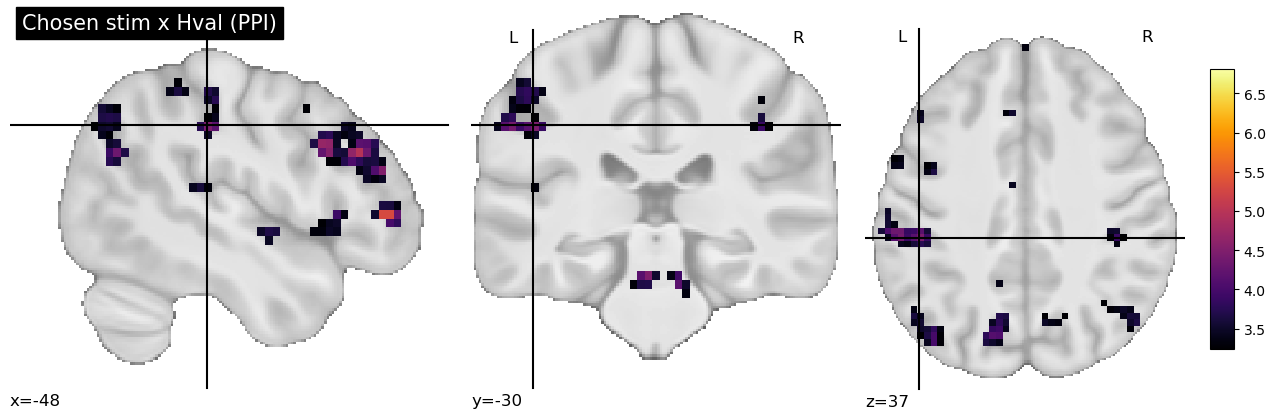

In [52]:
fig = plt.figure(figsize=(12, 4))

display = plotting.plot_anat(
    avg_T1,
    black_bg=False,
    title="Chosen stim x Hval (PPI)",
    display_mode="ortho",
    draw_cross=True,
    cut_coords=(-48, -30, 37.5),
    threshold=200,
    dim='auto',
    colorbar=False,
    figure=fig
)

display.add_overlay(
    masks["habit"],
    cmap=roi_cmps[2],
    transparency=0.7,
)

display.add_overlay(
    ppi_chosen_x_Hval,
    vmin=3.24,
    vmax=6.81,
    colorbar=False,
    cmap='inferno'
)

cax = fig.add_axes([1, 0.15, 0.02, 0.70])
norm = mpl.colors.Normalize(vmin=3.24, vmax=6.81)
cb = mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.inferno, norm=norm)

fig.savefig(f"{figures_dir}/PPI_chosen_x_Hval_ortho.png", dpi=300, bbox_inches='tight')
plotting.show()

In [ ]:
# Glass brain
fig = plt.figure(figsize=(10, 4))

display = plotting.plot_glass_brain(
    ppi_chosen_x_Hval,
    black_bg=False,
    title="Chosen stim x Hval (PPI, glass brain)",
    display_mode="ortho",
    figure=fig,
    threshold=3.24,
    vmin=3.24,
    vmax=6.81,
    colorbar=False,
    cmap='inferno',
)

display.add_overlay(
    masks["striatum"],
    cmap=roi_cmps[5],
    transparency=0.6,
)

cax = fig.add_axes([1, 0.15, 0.02, 0.70])
norm = mpl.colors.Normalize(vmin=3.24, vmax=6.81)
cb = mpl.colorbar.ColorbarBase(cax, cmap=mpl.cm.inferno, norm=norm)

fig.savefig(f"{figures_dir}/PPI_chosen_x_Hval_glass.png", dpi=300, bbox_inches='tight')
plotting.show()